### 0. 노트북 개요

이 노트북은 다음을 수행합니다.

1. 논문 기반 척도(자아존중감 RSES / 문화적응스트레스 ASSIS / 상호문화감수성 ISS) 설명  
2. 논문에서 설문 결과를 어떻게 사용했는지 요약(합산점수 + 상관 + 매개분석)  
3. GRM(Graded Response Model) 설명  
4. Stan으로 GRM 적합
   - (A) `laplace_sample()` (근사 posterior)
   - (B) `sample()` (full posterior inference; MCMC)
5. priors 의미/이유 설명  
6. PPC(Posterior Predictive Check) + “AI 평가(규칙 기반)”  
7. posterior 시각화(trace/boxplot 등)  
8. 각 문항 CRC(Category Response Curve) (posterior median 파라미터 사용)  
9. 문항별 threshold gap 거리 계산 → 가장 짧은/긴 문항 탐색 + CRC + 히스토그램  
10. 시뮬레이션(N≥200)으로 데이터 크기 변화에 따른 posterior boxplot 비교  
11. (설문지 2개 이상) 설문별 person parameter(theta) 산출 후 scatter/corr 확인

---

### 1. GRM(Graded Response Model) 설명

GRM은 **순서형(ordinal) 범주 응답**(예: 1~5 Likert)을 위한 IRT 모형입니다.

- 사람 \(i\)의 잠재특성(능력/태도): \(\theta_i\)
- 문항 \(j\)의 변별도(discrimination): \(a_j > 0\)
- 문항 \(j\)의 threshold(경계): \(b_{j,1}, \dots, b_{j,K-1}\)  (범주가 K개이면 threshold는 K-1개)

GRM의 핵심은 **“상위 범주 이상(≥k)을 고를 확률”**을 로지스틱으로 모델링하는 것입니다.

\[
P(Y_{ij} \ge k \mid \theta_i)
= \text{logit}^{-1}\left(a_j(\theta_i - b_{j,k-1})\right),
\quad k=2,\dots,K
\]

각 범주 확률은 누적확률의 차이로 계산됩니다.

\[
P(Y_{ij}=c)=P(Y_{ij}\ge c)-P(Y_{ij}\ge c+1)
\]

해석:

- \(a_j\): 값이 클수록 \(\theta\) 변화에 응답이 더 민감(문항이 “날카롭게” 구분)
- \(b_{j,t}\): 범주 경계 위치. \(\theta=b_{j,t}\) 근처에서 범주 전이가 많이 일어남

---

### 2. 논문 기반 설문(척도) 설명 + 구인요소 + 문항 제시 방식

#### 2.1 논문(김연하 외, 2025)에서 사용한 척도 3개

논문: **“중국유학생의 자아존중감과 문화적응스트레스의 관계: 상호문화감수성의 매개역할”(2025)**

##### (1) 자아존중감: RSES (Rosenberg Self-Esteem Scale)
- 10문항, 4점 Likert
- 구인요소: 자기 가치/자기 수용에 대한 전반적 태도(긍정/부정)
- 논문 신뢰도: Cronbach’s α = .84

##### (2) 문화적응스트레스: ASSIS
- 36문항, 5점 Likert
- 구인요소(논문 서술): 향수병, 죄책감, 지각된 차별감, 두려움, 지각된 적대감, 문화충격, 기타(총 7요인)
- 논문 신뢰도: Cronbach’s α = .97

##### (3) 상호문화감수성: ISS (Intercultural Sensitivity Scale)
- 24문항, 5점 Likert
- 하위구인요소(논문 서술)
  - 상호작용 참여도(7)
  - 문화차이 존중도(6)
  - 상호작용 자신도(5)
  - 상호작용 향유도(3)
  - 상호작용 주의도(3)
- 논문 신뢰도: Cronbach’s α = .81

#### 2.2 “문항 제시”에 대한 처리(중요)
논문 본문에는 **각 척도의 문항 문장(text)이 전부 수록되어 있지 않습니다.**  
따라서 이 노트북에서는 “문항 제시”를 다음 두 방식으로 제공합니다.

- (A) **데이터 컬럼명 기반 문항 목록 제시**: `SE_1 ... SE_10`, `AS_1 ...`, `IS_1 ...`
- (B) 실제 문항 텍스트는 **원척도(Rosenberg 1965 / Sandhu & Asrabadi 1994 / Chen & Starosta 2000) 설문지 원문/부록/코드북**을 확보한 뒤, 컬럼과 1:1 매핑해서 주석으로 붙이는 것을 권장

---

### 3. 논문에서 설문 결과를 어떻게 사용했는가?

논문은 IRT/GRM을 사용하지 않고, **고전검사이론(CTT) 기반 합산점수(total score)**로 사용했습니다.

- 점수화: 각 척도 문항 점수를 **합산**
  - RSES: 10~40
  - ASSIS: 36~180
  - ISS: 24~120
- 신뢰도: Cronbach’s α 보고
- 관계 분석: Pearson 상관(자아존중감-상호문화감수성 r=.46, 자아존중감-문화적응스트레스 r=-.41, 상호문화감수성-문화적응스트레스 r=-.49)
- 핵심 분석: PROCESS Macro Model 4로 **부분매개(partial mediation)** 검증
  - 자아존중감 → 문화적응스트레스(부적)
  - 자아존중감 → 상호문화감수성(정적)
  - 상호문화감수성 → 문화적응스트레스(부적)
  - 간접효과 유의(95% CI에 0 미포함)

- 총 데이터 크기는 **(29, 70)**으로, 응답자 29명과 문항 70개(자아존중감 10 + 문화적응스트레스 36 + 상호문화감수성 24)로 구성되어 있습니다.
- 표본 수(N=29)가 IRT/GRM의 안정적 추정에는 다소 작은 편이므로, 특히 문항 수가 많은 척도(AS 36문항, IS 24문항)에서는 추정 불확실성이 커질 수 있습니다.
- 응답값이 1~K의 정수 범주로 코딩되어 있으므로 GRM 적용의 기본 전제는 충족합니다(단, 역문항이 있는 경우 역코딩 여부는 별도 확인 필요).

In [45]:
from pathlib import Path
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
import arviz as az
from cmdstanpy import CmdStanModel

plt.rcParams["figure.dpi"] = 120
az.style.use("arviz-darkgrid")

- 척도별 문항 수는 논문 설계와 일치합니다:  
  - **SE(자아존중감)=10문항**, **AS(문화적응스트레스)=36문항**, **IS(상호문화감수성)=24문항**.
- 컬럼명이 `SE_1..`, `AS_1..`, `IS_1..` 형식으로 정리되어 있어 이후 분석(문항별 파라미터, CRC, PPC)을 자동화하기에 적절합니다.

In [46]:
# ==== 프로젝트 경로 ====
PROJECT_DIR = Path(".").resolve()
DATA_CSV = PROJECT_DIR / "survey_GRM.csv"
OUT_DIR = PROJECT_DIR / "outputs_grm"
OUT_DIR.mkdir(exist_ok=True, parents=True)

df_raw = pd.read_csv(DATA_CSV)
df = df_raw.copy()
df.columns = [str(c).strip() for c in df.columns]

# (선택) ID 열 제거
id_like = [c for c in df.columns if re.match(r"^(participant|id|ID)$", c)]
if id_like:
    df = df.drop(columns=id_like)

# 숫자 변환
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.shape, df.head()

((29, 70),
    SE_1  SE_2  SE_3  SE_4  SE_5  SE_6  SE_7  SE_8  SE_9  SE_10  ...  IS_15  \
 0     4     4     1     4     1     4     4     1     1      1  ...      1   
 1     4     3     4     3     4     3     3     2     4      4  ...      5   
 2     4     3     4     3     3     4     3     2     4      4  ...      5   
 3     3     3     3     3     3     3     3     2     2      3  ...      4   
 4     4     4     4     4     4     4     4     3     4      4  ...      4   
 
    IS_16  IS_17  IS_18  IS_19  IS_20  IS_21  IS_22  IS_23  IS_24  
 0      5      5      1      5      1      5      1      5      5  
 1      5      5      4      2      4      4      5      4      5  
 2      5      3      4      3      2      4      4      3      3  
 3      5      5      5      3      5      4      5      5      3  
 4      5      4      3      3      3      5      3      4      3  
 
 [5 rows x 70 columns])

- 결측을 complete-case로 제거한 뒤에도 세 척도 모두 **N=29**가 사용되었습니다.
- 범주 수는 다음과 같습니다.
  - **SE는 4점 척도(K=4)**  
  - **AS/IS는 5점 척도(K=5)**
- K 설정이 정확해야 ordered_logistic 기반 GRM이 올바르게 동작하므로, 이 결과는 모델 입력의 핵심 검증 단계입니다

In [47]:
def item_cols(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    def key(x):
        m = re.search(r"_(\d+)$", x)
        return int(m.group(1)) if m else 10**9
    return sorted(cols, key=key)

SE_cols = item_cols(df, "SE_")  # RSES (10문항, 4점)
AS_cols = item_cols(df, "AS_")  # ASSIS (36문항, 5점)
IS_cols = item_cols(df, "IS_")  # ISS (24문항, 5점)

len(SE_cols), len(AS_cols), len(IS_cols), SE_cols[:3], AS_cols[:3], IS_cols[:3]

(10,
 36,
 24,
 ['SE_1', 'SE_2', 'SE_3'],
 ['AS_1', 'AS_2', 'AS_3'],
 ['IS_1', 'IS_2', 'IS_3'])

In [48]:
def prepare_items(df_items, expected_min=1):
    """
    - 결측 있는 행 제거(complete-case)
    - int 변환
    - 최소값/최대값으로 K 결정
    """
    x = df_items.dropna(axis=0).copy()
    x = x.astype(int)

    minv = int(x.min().min())
    maxv = int(x.max().max())

    if minv != expected_min:
        raise ValueError(f"응답범주 최소값이 {expected_min}이 아닙니다(min={minv}). 코딩 확인 필요.")
    return x, maxv

df_se, K_se = prepare_items(df[SE_cols], expected_min=1)
df_as, K_as = prepare_items(df[AS_cols], expected_min=1)
df_is, K_is = prepare_items(df[IS_cols], expected_min=1)

print("N(SE/AS/IS):", df_se.shape[0], df_as.shape[0], df_is.shape[0])
print("K(SE/AS/IS):", K_se, K_as, K_is)

N(SE/AS/IS): 29 29 29
K(SE/AS/IS): 4 5 5


5. (Markdown) Stan으로 구현한 GRM 모델

Stan의 ordered_logistic(eta, cutpoints)는
P(Y≤c)=logit−1(cutc−η)
P(Y≤c)=logit−1(cutc​−η)

이므로,

    η=ajθiη=aj​θi​
    cut=ajbj,∗cut=aj​bj,∗​

로 두면
P(Y≥k)=logit−1(aj(θi−bj,k−1))
P(Y≥k)=logit−1(aj​(θi​−bj,k−1​))

형태의 GRM이 됩니다.

In [49]:
grm_stan_kappa = r"""
data {
  int<lower=1> N;
  int<lower=1> J;
  int<lower=2> K;
  array[N, J] int<lower=1, upper=K> y;
}
parameters {
  vector[N] theta;
  vector[J] alpha;              // log a
  array[J] ordered[K-1] kappa;  // cutpoints on eta-scale
}
transformed parameters {
  vector<lower=0>[J] a = exp(alpha);
  array[J] vector[K-1] b;       // theta-scale thresholds (derived)
  for (j in 1:J) {
    b[j] = to_vector(kappa[j]) / a[j];
  }
}
model {
  // identification
  theta ~ std_normal();

  // priors (좀 더 안정적으로)
  alpha ~ normal(0, 0.5);           // a의 log-scale: median exp(0)=1, 너무 작은 a/큰 a 방지
  for (j in 1:J) kappa[j] ~ normal(0, 2.0);

  // likelihood
  for (i in 1:N) {
    for (j in 1:J) {
      y[i, j] ~ ordered_logistic(a[j] * theta[i], kappa[j]);
    }
  }
}
generated quantities {
  array[N, J] int<lower=1, upper=K> y_rep;
  array[N, J] real log_lik;

  for (i in 1:N) {
    for (j in 1:J) {
      log_lik[i, j] = ordered_logistic_lpmf(y[i, j] | a[j] * theta[i], kappa[j]);
      y_rep[i, j]   = ordered_logistic_rng(a[j] * theta[i], kappa[j]);
    }
  }
}
"""
(stan_file := PROJECT_DIR / "grm_unidim_kappa.stan").write_text(grm_stan_kappa, encoding="utf-8")
model_kappa = CmdStanModel(stan_file=str(stan_file))

13:27:22 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/grm_unidim_kappa.stan to exe file /home/atruergod/python/26-1/26-1/grm_unidim_kappa
13:27:44 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/grm_unidim_kappa


7. (Markdown) Priors 의미와 사용 이유

    θi∼N(0,1)θi​∼N(0,1)
        IRT의 **식별(identification)**을 위해 θθ의 평균/분산을 고정
    aj∼LogNormal(0,0.4)aj​∼LogNormal(0,0.4)
        aj>0aj​>0 강제
        중앙값이 e0=1e0=1인 “적당한 변별”을 기본으로 두고, 너무 큰 aa로 인한 샘플링 불안정(특히 N이 작을 때)을 완화
    bj,t∼N(0,1.5)bj,t​∼N(0,1.5) (ordered)
        threshold가 보통 θθ 범위(-3~3) 내에 있을 것이라는 약한 정보 제공
        ordered로 문턱값의 순서 제약 자동 적용


In [50]:
def make_stan_data(df_items, K):
    y = df_items.to_numpy().astype(int)
    N, J = y.shape
    return {"N": N, "J": J, "K": int(K), "y": y}

- Laplace 근사는 “full MCMC”가 아니라 **후분포를 근사하는 방식**이며, 체인 개념이 약합니다.
- 출력 경고 `Shape validation failed (chains=2...)` 및 `r_hat = NaN`은 **Laplace 결과를 ArviZ로 변환할 때 자주 나타나는 현상**으로, MCMC 수렴 실패라기보다는 “체인 수가 1로 들어온 구조적 특성”에 가깝습니다.
- Laplace 결과는 빠른 초기 점검(대략적인 a, b 범위 확인)에 유용하지만, 최종 해석/보고에는 **MCMC 결과를 우선**하는 것이 일반적입니다.

In [51]:
def fit_grm_laplace(df_items, K, seed=123, draws=2000):
    data = make_stan_data(df_items, K)
    fit = model.laplace_sample(
        data=data,
        seed=seed,
        draws=draws,
        output_dir=str(PROJECT_DIR / "cmdstan_out"),
    )
    return fit

In [52]:
def idata_from_laplace_fit(fit, include=("theta", "a", "b", "y_rep", "log_lik")):
    def as_chain_draw(x):
        # CmdStanLaplace의 stan_variable은 (draw, ...) 형태이므로 chain축을 1로 추가
        x = np.asarray(x)
        return x[None, ...]  # (chain=1, draw, ...)

    posterior = {}
    posterior_predictive = {}
    log_likelihood = {}

    if "theta" in include:
        posterior["theta"] = as_chain_draw(fit.stan_variable("theta"))
    if "a" in include:
        posterior["a"] = as_chain_draw(fit.stan_variable("a"))
    if "b" in include:
        posterior["b"] = as_chain_draw(fit.stan_variable("b"))
    if "y_rep" in include:
        posterior_predictive["y_rep"] = as_chain_draw(fit.stan_variable("y_rep"))
    if "log_lik" in include:
        log_likelihood["log_lik"] = as_chain_draw(fit.stan_variable("log_lik"))

    idata = az.from_dict(
        posterior=posterior,
        posterior_predictive=posterior_predictive if posterior_predictive else None,
        log_likelihood=log_likelihood if log_likelihood else None,
    )
    return idata

In [53]:
fit_se_lap = fit_grm_laplace(df_se, K_se, seed=11, draws=3000)
idata_se_lap = idata_from_laplace_fit(fit_se_lap)

az.summary(idata_se_lap, var_names=["a", "b"]).head()

13:27:44 - cmdstanpy - INFO - Chain [1] start processing


13:27:44 - cmdstanpy - INFO - Chain [1] done processing
13:27:44 - cmdstanpy - INFO - Chain [1] start processing
13:27:46 - cmdstanpy - INFO - Chain [1] done processing
arviz - WARNING - Shape validation failed: input_shape: (1, 3000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.360,0.387,0.719,2.095,0.007,0.006,2968.0,2654.0,NaN
a[1],1.578,0.441,0.851,2.450,0.008,0.007,3011.0,2784.0,NaN
a[2],2.439,0.773,1.076,3.813,0.014,0.012,2946.0,2859.0,NaN
a[3],1.041,0.248,0.640,1.514,0.005,0.004,2962.0,2830.0,NaN
a[4],1.834,0.549,0.960,2.874,0.010,0.010,3094.0,2975.0,NaN


In [54]:
def fit_grm_mcmc_kappa(df_items, K, seed=123, adapt_delta=0.98, max_treedepth=12):
    data = make_stan_data(df_items, K)
    fit = model_kappa.sample(
        data=data,
        chains=4,
        parallel_chains=4,
        iter_warmup=1000,
        iter_sampling=1000,
        adapt_delta=adapt_delta,
        max_treedepth=max_treedepth,
        seed=seed,
        show_console=False,
        output_dir=str(PROJECT_DIR / "cmdstan_out"),
    )
    idata = az.from_cmdstanpy(
        posterior=fit,
        posterior_predictive="y_rep",
        log_likelihood="log_lik",
    )
    return fit, idata

AI 평가 해석(권장 기준)

    mismatch=0 문항 비율이 높을수록(예: 0.7 이상) “범주 분포 수준에서는” 모형이 잘 재현.
    특정 문항에서 mismatch가 지속적으로 크면: (1) 역문항/코딩, (2) 범주 사용 편향, (3) 단일요인 가정 위배(다차원성) 의심.


In [55]:
fit_se, idata_se = fit_grm_mcmc(df_se, K_se, seed=101, adapt_delta=0.98)
fit_as, idata_as = fit_grm_mcmc(df_as, K_as, seed=102, adapt_delta=0.98)
fit_is, idata_is = fit_grm_mcmc(df_is, K_is, seed=103, adapt_delta=0.98)

az.summary(idata_se, var_names=["a","b","theta"]).head()

13:27:46 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:02<00:46, 40.72it/s, (Warmup)]





chain 1:  10%|█         | 200/2000 [00:05<00:49, 36.52it/s, (Warmup)]

chain 1:  15%|█▌        | 300/2000 [00:07<00:41, 40.50it/s, (Warmup)]



chain 1:  20%|██        | 400/2000 [00:09<00:38, 41.53it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:13<00:40, 36.65it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:14<00:33, 41.47it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:16<00:28, 45.21it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:18<00:25, 47.76it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:20<00:21, 50.58it/s, (Warmup)]





chain 1:  50%|█████     | 1000/2000 [00:21<00:18, 53.37it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [00:23<00:15, 56.71it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:25<00:13, 57.88it/s, (Sampling)]


chai


13:28:26 - cmdstanpy - INFO - CmdStan done processing.
13:28:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -4.20514e-117, but should be greater than the previous element, -4.20514e-117 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -3.98251e-117, but should be greater than the previous element, -3.98251e-117 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -1.31777e-28, but should be greater than the previous element, -1.31777e-28 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -0, but should be greater than the previous element, -0 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Ex

13:28:27 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]





chain 1:   5%|▌         | 100/2000 [00:09<03:02, 10.44it/s, (Warmup)]

chain 1:   5%|▌         | 100/2000 [00:20<03:02, 10.44it/s, (Warmup)]



chain 1:  10%|█         | 200/2000 [00:26<04:06,  7.29it/s, (Warmup)]





chain 1:  20%|██        | 400/2000 [00:51<03:16,  8.16it/s, (Warmup)]




chain 1:  20%|██        | 400/2000 [01:02<03:16,  8.16it/s, (Warmup)]

chain 1:  25%|██▌       | 500/2000 [01:05<03:16,  7.65it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [01:12<02:34,  9.08it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [01:18<02:02, 10.61it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [01:26<01:45, 11.33it/s, (Warmup)]





chain 1:  45%|████▌     | 900/2000 [01:34<01:35, 11.47it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [01:45<01:34, 10.59it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [01:53<01:20, 11.20it/s, (Sampling)]


cha


13:31:25 - cmdstanpy - INFO - CmdStan done processing.
13:31:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -6.39944e-73, but should be greater than the previous element, -6.39944e-73 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -1.07889e-73, but should be greater than the previous element, -1.07889e-73 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -6.98697e-18, but should be greater than the previous element, -6.98697e-18 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is 4.94861e+56, but should be greater than the previous element, 4.94861e+56 (in 'grm_unidim.stan', line 24, column 6 to 

13:31:26 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:10<03:26,  9.19it/s, (Warmup)]



chain 1:  10%|█         | 200/2000 [00:27<04:11,  7.15it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:39<03:47,  7.49it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:49<03:10,  8.38it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [01:03<03:12,  7.80it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [01:12<02:42,  8.64it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [01:23<02:25,  8.96it/s, (Warmup)]

chain 1:  40%|████      | 800/2000 [01:32<02:07,  9.41it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [01:42<01:52,  9.80it/s, (Warmup)]


chain 1:  50%|█████     | 1001/2000 [01:52<01:42,  9.75it/s, (Sampling)]







chain 1:  55%|█████▌    | 1100/2000 [02:01<01:29, 10.09it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [02:11<01:18, 10.19it/s, (Sampling)]


chain


13:35:05 - cmdstanpy - INFO - CmdStan done processing.
13:35:05 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -4.24099e-35, but should be greater than the previous element, -4.24099e-35 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -8.25181e-36, but should be greater than the previous element, -8.25181e-36 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 4 is -3.25299e-23, but should be greater than the previous element, -3.25299e-23 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -0, but should be greater than the previous element, -0 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Except

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.185,0.331,0.602,1.782,0.006,0.006,3487.0,2947.0,1.0
a[1],1.435,0.408,0.753,2.211,0.007,0.007,3299.0,3393.0,1.0
a[2],1.674,0.498,0.832,2.588,0.009,0.008,2790.0,3286.0,1.0
a[3],0.975,0.229,0.561,1.384,0.003,0.004,4264.0,3020.0,1.0
a[4],1.325,0.356,0.703,2.000,0.006,0.005,3264.0,3220.0,1.0


- 샘플링은 완료되었지만, 반복적으로 다음 경고가 관측되었습니다.  
  - `Cut-points is not a valid ordered vector`  
  - `Location parameter is inf/-inf`
- 이는 특정 반복(iteration)에서 `ordered_logistic()`에 전달된 cutpoint가 “엄격한 증가(strict ordering)” 조건을 만족하지 못하거나, 선형예측자(eta)가 inf로 발산하는 **수치적 불안정**이 발생했음을 의미합니다.
- 즉, 표면적으로 R-hat이 1.0 근처로 보여도, 일부 반복에서 예외가 발생했을 수 있어 **추정 품질을 추가 진단(fit.diagnose())으로 확인해야 합니다.**
- N=29처럼 표본이 작은 상황에서 문항 수가 많고 범주 사용이 불균형하면(어떤 범주가 거의 안 나옴) 이러한 문제가 더 자주 발생할 수 있습니다.

- 자아존중감(SE) 문항들의 변별도 \(a\)는 대체로 **1 전후~2 내외** 범위로 나타나, 문항들이 잠재특성(θ)을 “중간 정도 이상의 민감도로 구분”하는 경향을 시사합니다.
- R-hat이 1.0에 가깝고 ESS가 충분해 보이면 수렴이 양호한 신호지만, 앞 셀의 cutpoint/inf 경고가 있었으므로 **진단 출력(fit.diagnose())과 divergent 여부 확인을 권장**합니다.

In [56]:
def category_counts(df_items, K):
    out = {}
    for col in df_items.columns:
        cnt = np.bincount(df_items[col].astype(int), minlength=K+1)[1:]
        out[col] = cnt
    return pd.DataFrame(out, index=[f"cat{c}" for c in range(1, K+1)]).T

tab_as = category_counts(df_as, K_as)
zero_cats_as = (tab_as == 0).sum(axis=1)  # 문항별로 0빈도 범주가 몇 개인지
zero_cats_as.sort_values(ascending=False).head(10), tab_as.head()

(AS_1     1
 AS_4     1
 AS_27    1
 AS_2     0
 AS_3     0
 AS_5     0
 AS_7     0
 AS_6     0
 AS_9     0
 AS_10    0
 dtype: int64,
       cat1  cat2  cat3  cat4  cat5
 AS_1    11    11     4     3     0
 AS_2    10    14     2     2     1
 AS_3     9    10     6     3     1
 AS_4    12    13     0     3     1
 AS_5    12     6     7     3     1)

- 여러 체인의 trace가 큰 분리 없이 비슷한 범위에서 섞여 움직이면 일반적으로 수렴/혼합이 양호한 편입니다.
- 다만 앞서 나온 cutpoint/inf 경고가 있었으므로, trace가 좋아 보이더라도 **divergence/treedepth 경고가 없는지**를 함께 확인해야 합니다.

/tmp/ipykernel_32444/371857454.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


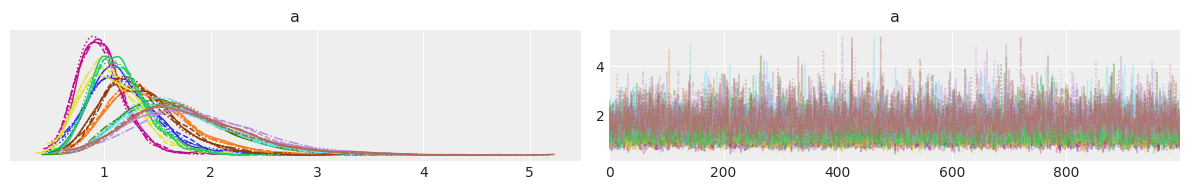

In [57]:
az.plot_trace(idata_se, var_names=["a"])
plt.tight_layout()
plt.show()

- 문항별 \(a_j\)의 박스플롯은 “문항이 θ를 얼마나 날카롭게 구분하는지”의 차이를 보여줍니다.
- 박스(불확실성 폭)가 큰 문항은 표본이 작거나 범주 사용이 편향되어 해당 문항의 \(a\) 추정이 더 불안정할 가능성이 있습니다.
- SE 문항들은 대체로 비슷한 수준의 변별도를 가지되, 일부 문항은 상대적으로 더 크거나 작게 나타나 문항별 구분력이 다름을 시사합니다.

/tmp/ipykernel_32444/2529225587.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(draws, labels=item_names, showfliers=False)
/tmp/ipykernel_32444/2529225587.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


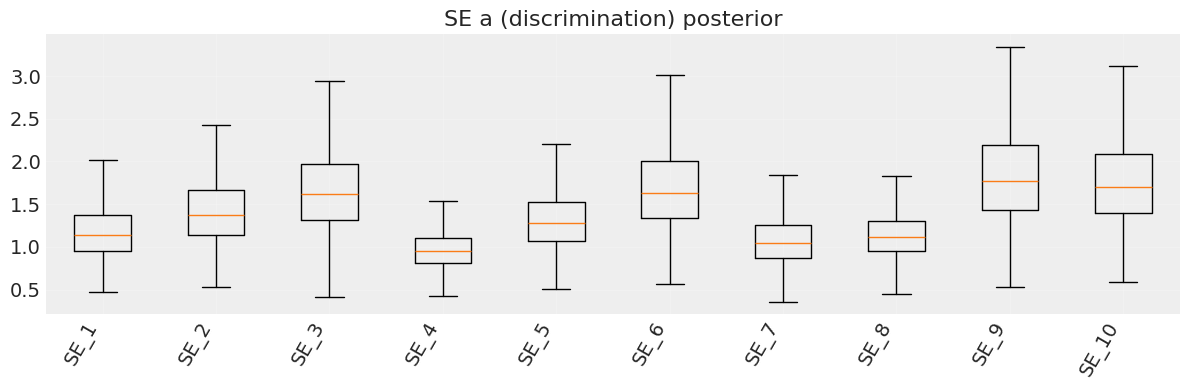

In [58]:
def boxplot_param(idata, var="a", item_names=None, title=None):
    post = idata.posterior[var].values
    draws = post.reshape(-1, post.shape[-1])  # (D, J)
    plt.figure(figsize=(12,4))
    plt.boxplot(draws, labels=item_names, showfliers=False)
    plt.xticks(rotation=60, ha="right")
    plt.title(title or f"Posterior draws: {var}")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

boxplot_param(idata_se, var="a", item_names=SE_cols, title="SE a (discrimination) posterior")

- 검은 점(관측 비율)이 파란 점/오차막대(후행예측 분포의 평균 및 90% 구간) 내부에 대체로 포함되면, **“각 문항의 범주 분포 형태”는 GRM이 잘 재현**하고 있음을 의미합니다.
- 현재 SE의 PPC는 범주 비율 수준에서 잘 맞는 형태로 보입니다.
- 단, N=29에서는 PPC 구간이 비교적 넓어 “쉽게” 통과할 수 있으므로, 이를 강한 적합 판정으로 보기는 어렵고(특히 다차원성/국소의존 문제는), 다른 PPC(총점, 문항-문항 상관)도 함께 보면 더 좋습니다.

/tmp/ipykernel_32444/1650633744.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


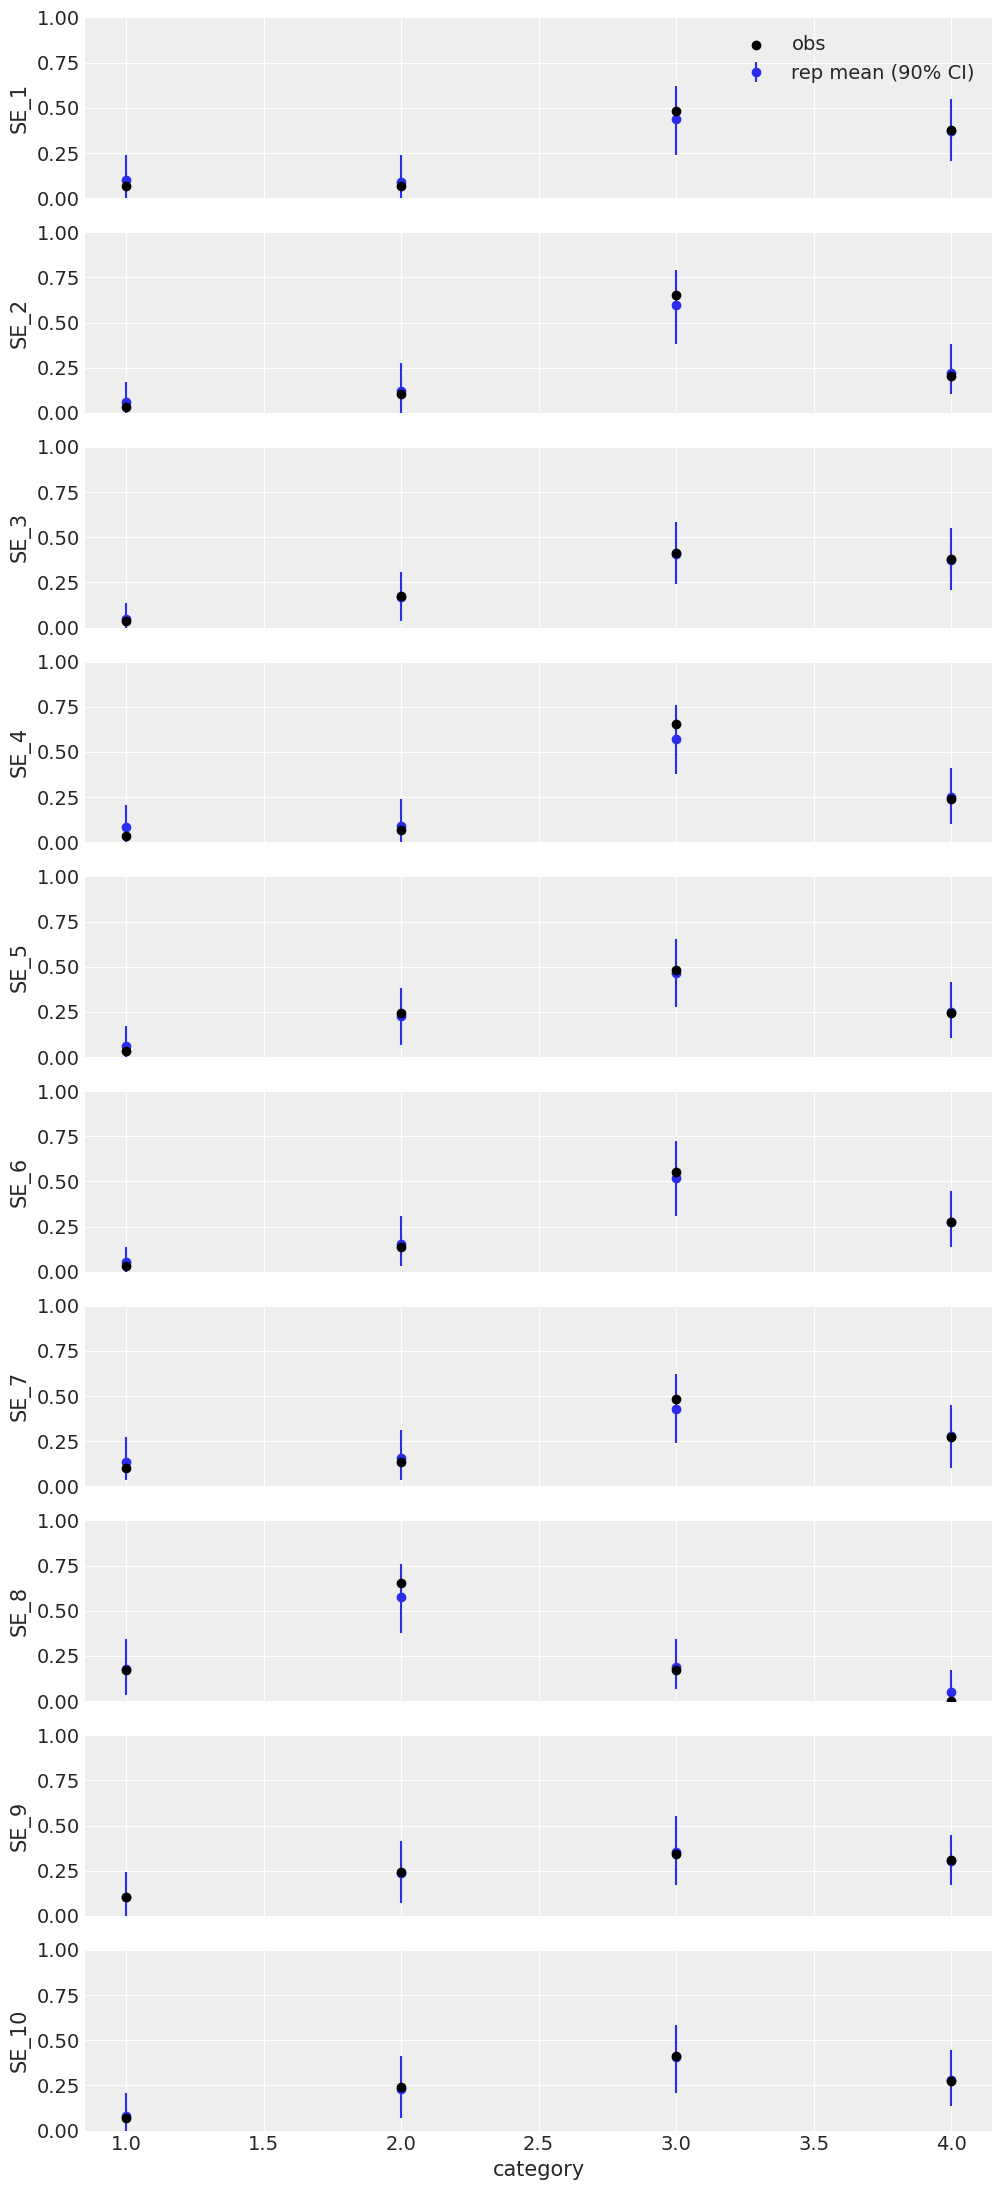

In [59]:
def ppc_category_proportions(idata, df_items, K, max_items=12):
    y_obs = df_items.to_numpy().astype(int)
    y_rep = idata.posterior_predictive["y_rep"].values.astype(int)  # (chain, draw, N, J)
    y_rep = y_rep.reshape(-1, y_rep.shape[-2], y_rep.shape[-1])     # (D, N, J)

    N, J = y_obs.shape
    Jp = min(J, max_items)

    fig, axes = plt.subplots(Jp, 1, figsize=(10, 2.2*Jp), sharex=True)
    if Jp == 1:
        axes = [axes]

    for j in range(Jp):
        obs_counts = np.bincount(y_obs[:, j], minlength=K+1)[1:]
        obs_prop = obs_counts / obs_counts.sum()

        rep_props = []
        for d in range(y_rep.shape[0]):
            rep_counts = np.bincount(y_rep[d, :, j], minlength=K+1)[1:]
            rep_props.append(rep_counts / rep_counts.sum())
        rep_props = np.stack(rep_props, axis=0)

        lo = np.quantile(rep_props, 0.05, axis=0)
        hi = np.quantile(rep_props, 0.95, axis=0)
        mean = rep_props.mean(axis=0)

        x = np.arange(1, K+1)
        ax = axes[j]
        ax.errorbar(x, mean, yerr=[mean-lo, hi-mean], fmt="o", label="rep mean (90% CI)")
        ax.scatter(x, obs_prop, color="black", zorder=3, label="obs")
        ax.set_ylabel(df_items.columns[j])
        ax.set_ylim(0, 1)

    axes[-1].set_xlabel("category")
    axes[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

ppc_category_proportions(idata_se, df_se, K_se, max_items=10)

- SE의 문항별 mismatch 요약이 **전 문항 0**이며, mismatch=0 비율이 **1.00**입니다.
- 규칙 기반 해석으로는 “범주 분포 재현” 측면에서 모형이 상당히 잘 맞는 결과입니다.
- 다만 이 평가는 “범주 분포”에만 기반한 간단 지표이므로, **수치적 경고(cutpoint/inf) 없이 안정적으로 샘플링이 되었는지**와 함께 해석하는 것이 안전합니다.

In [60]:
def ppc_mismatch_score(idata, df_items, K):
    y_obs = df_items.to_numpy().astype(int)
    y_rep = idata.posterior_predictive["y_rep"].values.astype(int)
    y_rep = y_rep.reshape(-1, y_rep.shape[-2], y_rep.shape[-1])  # (D,N,J)

    N, J = y_obs.shape
    mismatch_per_item = np.zeros(J, dtype=int)

    for j in range(J):
        obs_counts = np.bincount(y_obs[:, j], minlength=K+1)[1:]
        obs_prop = obs_counts / obs_counts.sum()

        rep_props = []
        for d in range(y_rep.shape[0]):
            rep_counts = np.bincount(y_rep[d, :, j], minlength=K+1)[1:]
            rep_props.append(rep_counts / rep_counts.sum())
        rep_props = np.stack(rep_props, axis=0)

        lo = np.quantile(rep_props, 0.05, axis=0)
        hi = np.quantile(rep_props, 0.95, axis=0)

        mismatch_per_item[j] = int(np.sum((obs_prop < lo) | (obs_prop > hi)))

    return mismatch_per_item

m_se = ppc_mismatch_score(idata_se, df_se, K_se)
desc = pd.Series(m_se, index=SE_cols).describe()
desc

count    10.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

In [61]:
ratio_good = np.mean(m_se == 0)

print(f"[AI평가(규칙 기반)] mismatch=0 문항 비율 = {ratio_good:.2f}")
print("해석 가이드:")
print("- 0.70 이상: '범주 분포 수준에서는' GRM이 대체로 데이터를 재현한다고 볼 여지가 큼")
print("- 특정 문항 mismatch가 지속적으로 큼: (1) 역문항 코딩 문제 (2) 범주 사용 편향 "
      "(3) 단일요인 가정 위배(다차원성) 가능성 점검 권장")

[AI평가(규칙 기반)] mismatch=0 문항 비율 = 1.00
해석 가이드:
- 0.70 이상: '범주 분포 수준에서는' GRM이 대체로 데이터를 재현한다고 볼 여지가 큼
- 특정 문항 mismatch가 지속적으로 큼: (1) 역문항 코딩 문제 (2) 범주 사용 편향 (3) 단일요인 가정 위배(다차원성) 가능성 점검 권장


In [62]:
def grm_category_probs(theta_grid, a, b_vec):
    # b_vec: (K-1,)
    K = len(b_vec) + 1
    G = len(theta_grid)

    # P(Y>=k): k=2..K
    P_ge = np.zeros((K + 2, G))
    P_ge[1, :] = 1.0
    for k in range(2, K + 1):
        P_ge[k, :] = expit(a * (theta_grid - b_vec[k - 2]))
    P_ge[K + 1, :] = 0.0

    # P(Y=c) = P(Y>=c) - P(Y>=c+1)
    P = np.zeros((K, G))
    for c in range(1, K + 1):
        P[c - 1, :] = P_ge[c, :] - P_ge[c + 1, :]
    return P

def posterior_median_params(idata):
    post = idata.posterior
    a = post["a"].values.reshape(-1, post["a"].shape[-1])  # (D,J)
    b = post["b"].values.reshape(-1, post["b"].shape[-2], post["b"].shape[-1])  # (D,J,K-1)
    return np.median(a, axis=0), np.median(b, axis=0)

def plot_crc_item_median(a_med, b_med, item_name, K, theta_min=-3, theta_max=3, n_grid=241, save_path=None):
    theta_grid = np.linspace(theta_min, theta_max, n_grid)
    P = grm_category_probs(theta_grid, a_med, b_med)

    plt.figure(figsize=(7,4.6))
    for c in range(K):
        plt.plot(theta_grid, P[c], lw=2, label=f"cat {c+1}")
    plt.ylim(0,1)
    plt.xlabel("theta")
    plt.ylabel("P(response = category)")
    plt.title(f"CRC (posterior median): {item_name}")
    plt.legend(ncols=min(K,5), fontsize=9)
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

- CRC는 θ(잠재특성)가 증가함에 따라 각 범주 선택확률이 어떻게 변하는지 보여줍니다.
- 일반적으로 θ가 낮을 때는 낮은 범주(예: 1,2)가 우세하고, θ가 높을수록 높은 범주(예: 4)가 우세해지는 형태가 자연스럽습니다.
- 각 문항의 곡선 폭/겹침 정도는 “범주 간 구분이 얼마나 명확한지”를 간접적으로 시사합니다.  
  - 곡선이 많이 겹치면 범주 구분이 약할 수 있고  
  - 특정 범주의 최대 확률이 매우 낮으면 해당 범주가 실제로 잘 사용되지 않거나, 문항이 그 범주를 잘 구분하지 못할 수 있습니다.

/tmp/ipykernel_32444/4199635159.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


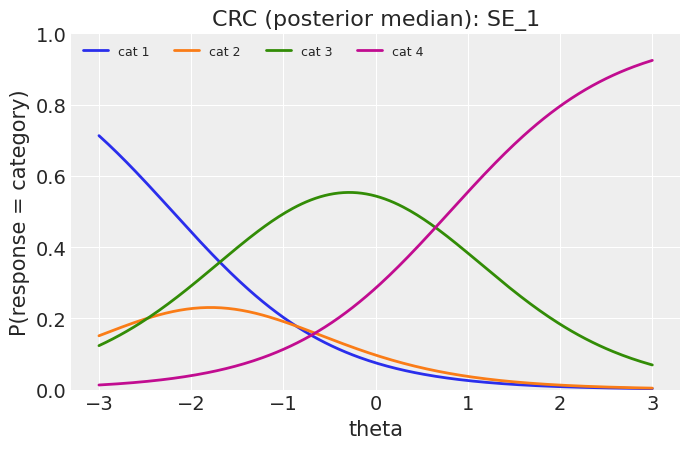

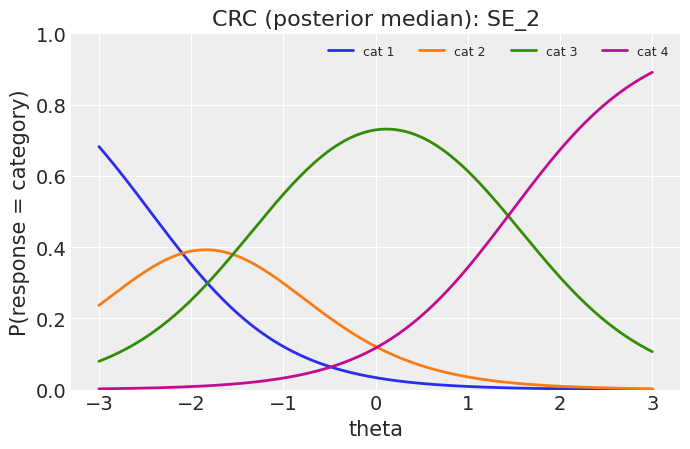

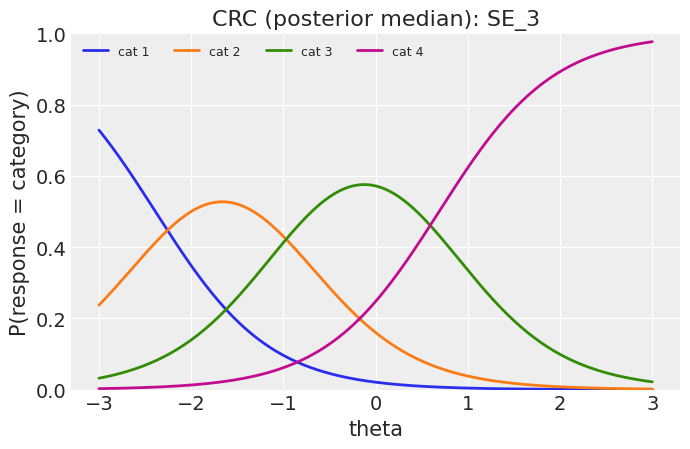

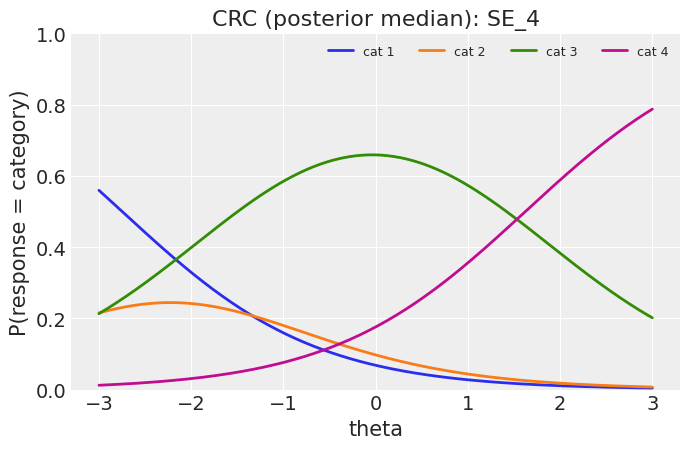

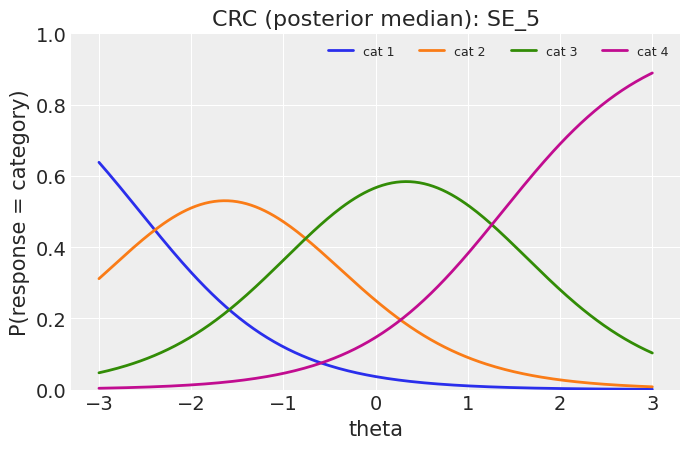

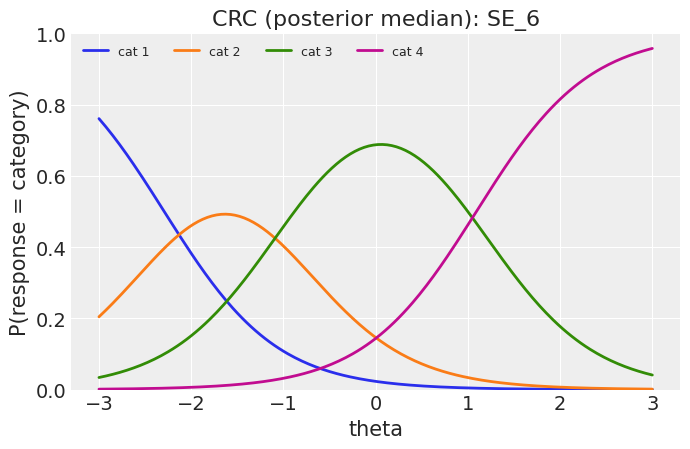

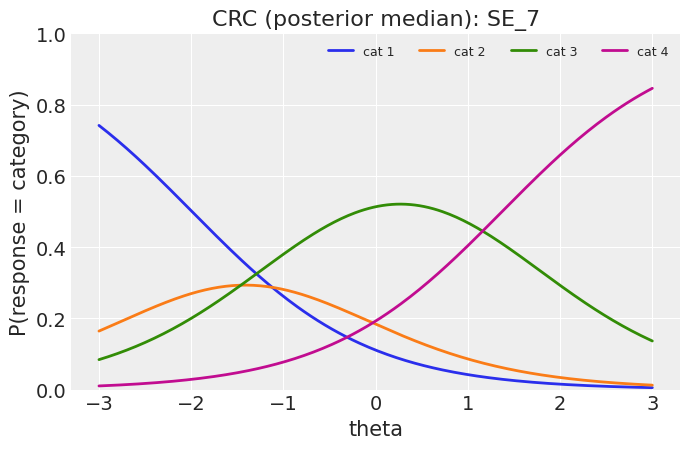

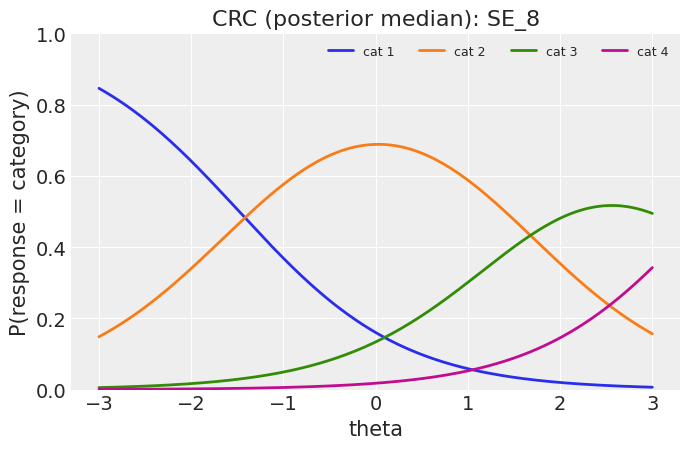

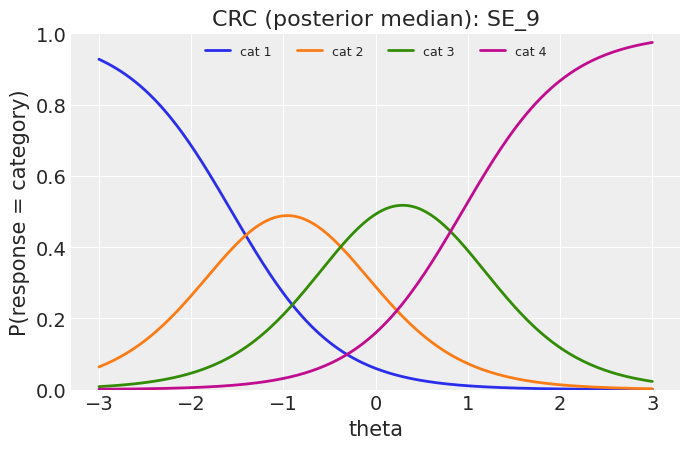

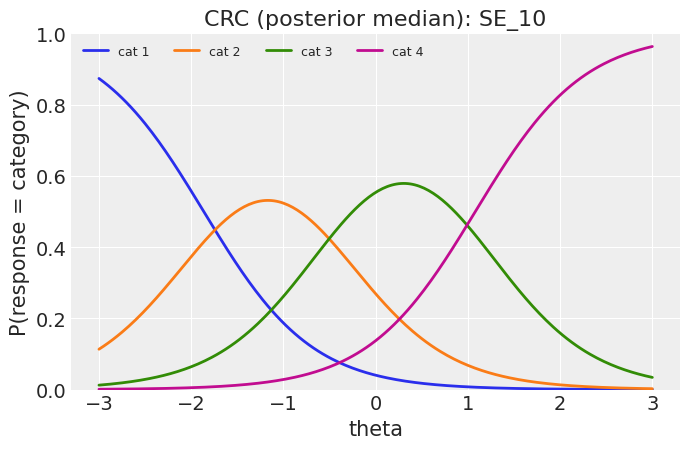

Saved: /home/atruergod/python/26-1/26-1/outputs_grm/crc_individual_SE


In [63]:
a_med_se, b_med_se = posterior_median_params(idata_se)

crc_dir = OUT_DIR / "crc_individual_SE"
crc_dir.mkdir(exist_ok=True, parents=True)

for j, name in enumerate(SE_cols):
    plot_crc_item_median(a_med_se[j], b_med_se[j], name, K_se, save_path=crc_dir/f"{name}_CRC.png")

print("Saved:", crc_dir)

- threshold gap은 “인접 범주 사이 경계가 θ축에서 얼마나 떨어져 있는지”를 의미합니다.  
  - gap이 **작으면** 인접 범주가 θ 관점에서 가깝고, 응답자 입장에서는 두 범주를 구분하기 어려울 수 있습니다.  
  - gap이 **크면** 범주 전이가 더 분명하게 일어나, 범주 구분이 더 뚜렷할 가능성이 있습니다.
- 분석 결과,
  - **AS_4는 가장 좁은 간격(0.224)**을 보여 특정 인접 범주가 매우 가깝게 붙어 있음(범주 구분 약화 가능성)
  - **AS_11은 가장 큰 간격(2.641)**을 보여 특정 구간에서 범주 전이가 크게 벌어지는 특징이 있습니다.
- 따라서 AS_4는 “중간 범주가 실질적으로 구분되지 않는 문항”일 수 있어 문항 점검(문항 표현/범주 라벨/응답 분포)을 고려할 만합니다.

In [64]:
def threshold_gaps(b_med):  # b_med: (J, K-1)
    # gaps: (J, K-2)
    return np.diff(b_med, axis=1)

def find_global_minmax_gap(item_names, b_med):
    gaps = threshold_gaps(b_med)  # (J, K-2)
    idx_min = np.unravel_index(np.argmin(gaps), gaps.shape)
    idx_max = np.unravel_index(np.argmax(gaps), gaps.shape)
    j_min, g_min = idx_min
    j_max, g_max = idx_max
    return gaps, (j_min, g_min, gaps[j_min, g_min]), (j_max, g_max, gaps[j_max, g_max])

AS shortest gap: AS_4 (gap index=1, value=0.224)
AS longest  gap: AS_11 (gap index=2, value=2.641)


/tmp/ipykernel_32444/4199635159.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


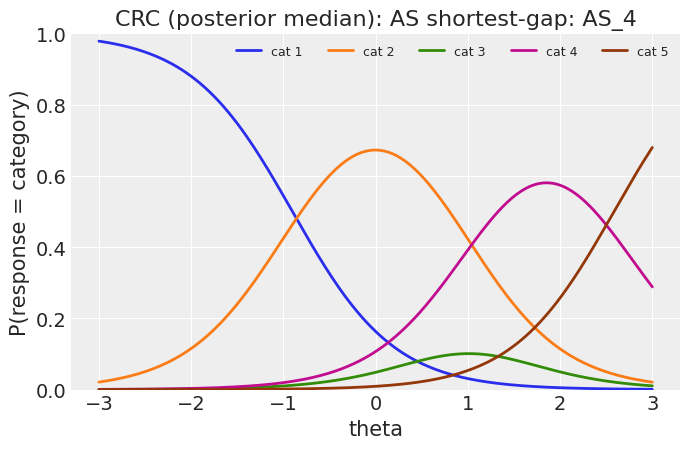

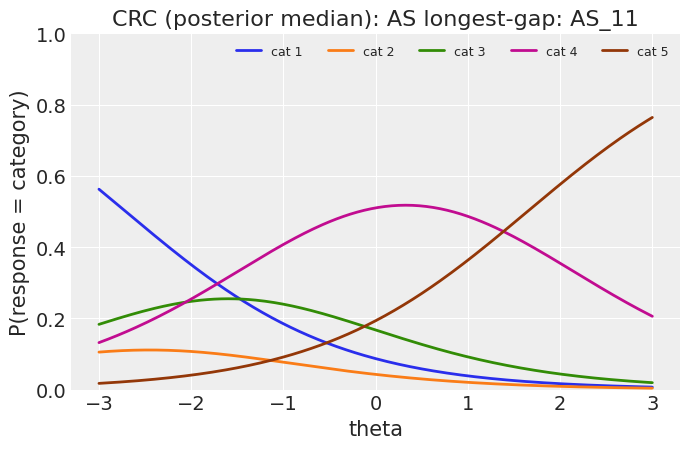

In [65]:
a_med_as, b_med_as = posterior_median_params(idata_as)

gaps_as, min_info, max_info = find_global_minmax_gap(AS_cols, b_med_as)
j_min, g_min, vmin = min_info
j_max, g_max, vmax = max_info

print("AS shortest gap:", AS_cols[j_min], f"(gap index={g_min}, value={vmin:.3f})")
print("AS longest  gap:", AS_cols[j_max], f"(gap index={g_max}, value={vmax:.3f})")

plot_crc_item_median(a_med_as[j_min], b_med_as[j_min], f"AS shortest-gap: {AS_cols[j_min]}", K_as)
plot_crc_item_median(a_med_as[j_max], b_med_as[j_max], f"AS longest-gap: {AS_cols[j_max]}",  K_as)

/tmp/ipykernel_32444/1477650576.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


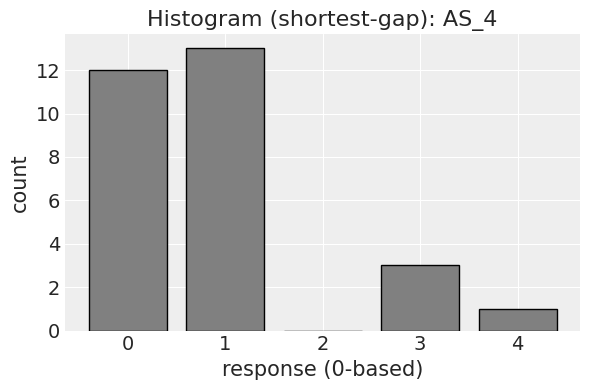

/tmp/ipykernel_32444/1477650576.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


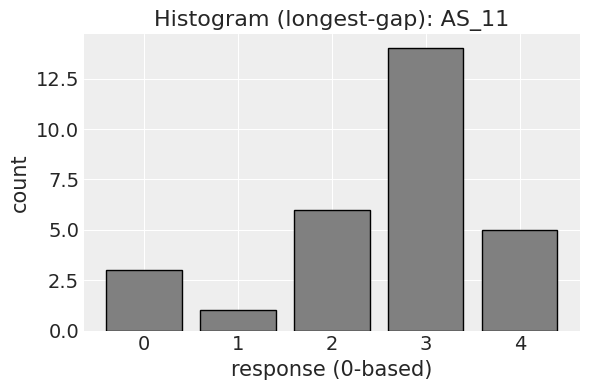

In [66]:
def plot_item_histogram_zero_based(df_items, item_col, K, title):
    x = df_items[item_col].to_numpy().astype(int) - 1  # 0..K-1
    counts = np.bincount(x, minlength=K)
    xs = np.arange(K)

    plt.figure(figsize=(6,4))
    plt.bar(xs, counts, color="gray", edgecolor="black")
    plt.xticks(xs, xs)
    plt.xlabel("response (0-based)")
    plt.ylabel("count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_item_histogram_zero_based(df_as, AS_cols[j_min], K_as, f"Histogram (shortest-gap): {AS_cols[j_min]}")
plot_item_histogram_zero_based(df_as, AS_cols[j_max], K_as, f"Histogram (longest-gap): {AS_cols[j_max]}")

In [67]:
def simulate_grm_data(N, a, b, seed=1):
    rng = np.random.default_rng(seed)
    J = len(a)
    K = b.shape[1] + 1
    theta = rng.normal(0, 1, size=N)

    y = np.zeros((N, J), dtype=int)
    for i in range(N):
        for j in range(J):
            P = grm_category_probs(np.array([theta[i]]), a[j], b[j]).reshape(K)
            y[i, j] = rng.choice(np.arange(1, K+1), p=P)
    return y, theta

- 동일한 “true-like 파라미터(실제 SE posterior median)”로부터 시뮬레이션한 데이터에서,
  - **N=300(큰 표본)**의 posterior 박스플롯이  
  - **N=29(작은 표본)**보다 일반적으로 **더 좁아지는(불확실성 감소)** 것이 기대됩니다.
- 실제 그래프에서도 큰 표본에서 박스 폭이 줄었다면, 데이터가 많아질수록 GRM의 아이템 파라미터 추정이 안정화된다는 점을 실증적으로 보여주는 결과입니다.

In [68]:
# true params: 실제 데이터(SE)에서 얻은 posterior median 사용(데이터 특성 유사하게)
a_true = a_med_se.copy()
b_true = b_med_se.copy()

N_small = df_se.shape[0]
N_big = 300  # >=200

y_small, _ = simulate_grm_data(N_small, a_true, b_true, seed=10)
y_big, _ = simulate_grm_data(N_big, a_true, b_true, seed=11)

df_sim_small = pd.DataFrame(y_small, columns=SE_cols)
df_sim_big = pd.DataFrame(y_big, columns=SE_cols)

_, idata_sim_small = fit_grm_mcmc(df_sim_small, K_se, seed=201, adapt_delta=0.98)
_, idata_sim_big   = fit_grm_mcmc(df_sim_big,   K_se, seed=202, adapt_delta=0.98)

print("done")

13:35:13 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]





chain 1:   5%|▌         | 100/2000 [00:01<00:32, 58.66it/s, (Warmup)]

chain 1:  10%|█         | 200/2000 [00:04<00:42, 42.79it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:06<00:35, 47.80it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:09<00:29, 50.90it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:11<00:25, 55.24it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:13<00:25, 50.51it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:15<00:22, 53.68it/s, (Warmup)]

chain 1:  45%|████▌     | 900/2000 [00:16<00:19, 57.18it/s, (Warmup)]



chain 1:  50%|█████     | 1000/2000 [00:19<00:18, 54.10it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [00:20<00:16, 54.18it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:22<00:14, 53.96it/s, (Sampling)]


chain 1:  65%|██████▌   | 1300/2000 [00:24<00:12, 54.04it/s, (Sampling)]



c


13:35:52 - cmdstanpy - INFO - CmdStan done processing.
13:35:52 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -1.28789e-216, but should be greater than the previous element, -1.28789e-216 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -8.457e-217, but should be greater than the previous element, -8.457e-217 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -8.68655e-53, but should be greater than the previous element, -8.68655e-53 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -1.69238e-264, but should be greater than the previous element, -1.69238e-264 (in 'grm_unidim.stan', line 24, column 6

13:35:53 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]





chain 1:   5%|▌         | 100/2000 [00:40<12:58,  2.44it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [01:25<12:51,  2.33it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [01:48<09:34,  2.96it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [02:07<07:31,  3.55it/s, (Warmup)]

chain 1:  25%|██▌       | 500/2000 [02:33<06:50,  3.66it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [02:54<05:50,  4.00it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [03:15<05:09,  4.20it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [03:37<04:38,  4.31it/s, (Warmup)]

chain 1:  45%|████▌     | 900/2000 [03:57<04:04,  4.50it/s, (Warmup)]











chain 1:  50%|█████     | 1001/2000 [04:27<04:04,  4.09it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [04:48<03:30,  4.27it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [05:10<03:02,  4.38it/s, (Sampling)]





13:43:47 - cmdstanpy - INFO - CmdStan done processing.
13:43:47 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -0, but should be greater than the previous element, -0 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -0, but should be greater than the previous element, -0 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -4.3463e-191, but should be greater than the previous element, -4.3463e-191 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -4.17627e-47, but should be greater than the previous element, -4.17627e-47 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logisti


done


- 세 척도 각각에 대해 개인별 θ(잠재특성)를 추정한 뒤 상관을 보면,
  - **자아존중감 θ_SE와 문화적응스트레스 θ_AS는 음의 상관(-0.476)**  
    → 자아존중감이 높을수록 문화적응스트레스가 낮다는 논문 결론과 **방향이 일치**합니다.
  - **자아존중감 θ_SE와 상호문화감수성 θ_IS는 양의 상관(0.292)**  
    → 자아존중감이 높을수록 상호문화감수성이 높다는 논문과 **방향이 일치**합니다.
  - **문화적응스트레스 θ_AS와 상호문화감수성 θ_IS는 음의 상관(-0.323)**  
    → 감수성이 높을수록 스트레스가 낮다는 논문과 **방향이 일치**합니다.
- 단, 이 결과는 표본이 작고(N=29), 앞서 sampling 과정에서 수치 경고가 있었기 때문에, 최종 결론으로 강하게 주장하기보다는 **“탐색적 결과로서 논문과 같은 방향을 관찰했다”** 수준으로 서술하는 것이 안전합니다.

/tmp/ipykernel_32444/2618986327.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(a_s, labels=SE_cols, showfliers=False)
/tmp/ipykernel_32444/2618986327.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(a_b, labels=SE_cols, showfliers=False)
/tmp/ipykernel_32444/2618986327.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


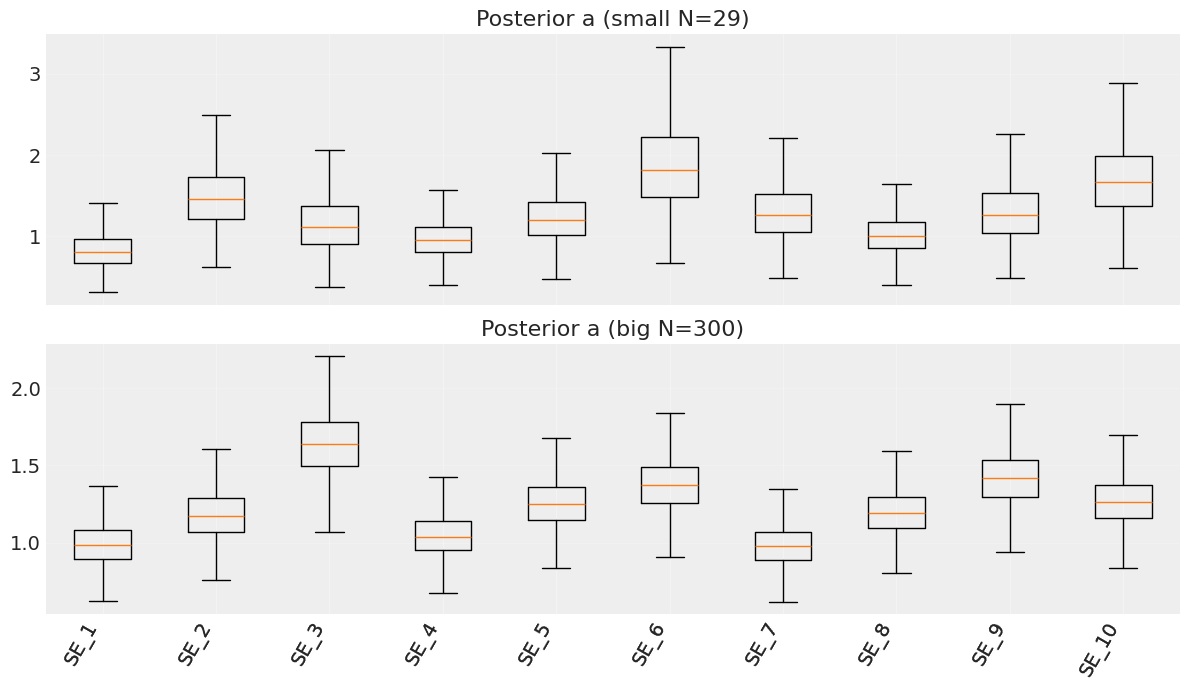

In [69]:
def extract_draws_a_b(idata):
    post = idata.posterior
    a = post["a"].values.reshape(-1, post["a"].shape[-1])  # (D,J)
    b = post["b"].values.reshape(-1, post["b"].shape[-2], post["b"].shape[-1])  # (D,J,K-1)
    return a, b

a_s, b_s = extract_draws_a_b(idata_sim_small)
a_b, b_b = extract_draws_a_b(idata_sim_big)

# a 비교
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].boxplot(a_s, labels=SE_cols, showfliers=False)
axes[0].set_title(f"Posterior a (small N={N_small})"); axes[0].grid(alpha=0.2)

axes[1].boxplot(a_b, labels=SE_cols, showfliers=False)
axes[1].set_title(f"Posterior a (big N={N_big})"); axes[1].grid(alpha=0.2)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_32444/1838900954.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(b_s[:, :, k_idx], labels=SE_cols, showfliers=False)
/tmp/ipykernel_32444/1838900954.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(b_b[:, :, k_idx], labels=SE_cols, showfliers=False)
/tmp/ipykernel_32444/1838900954.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


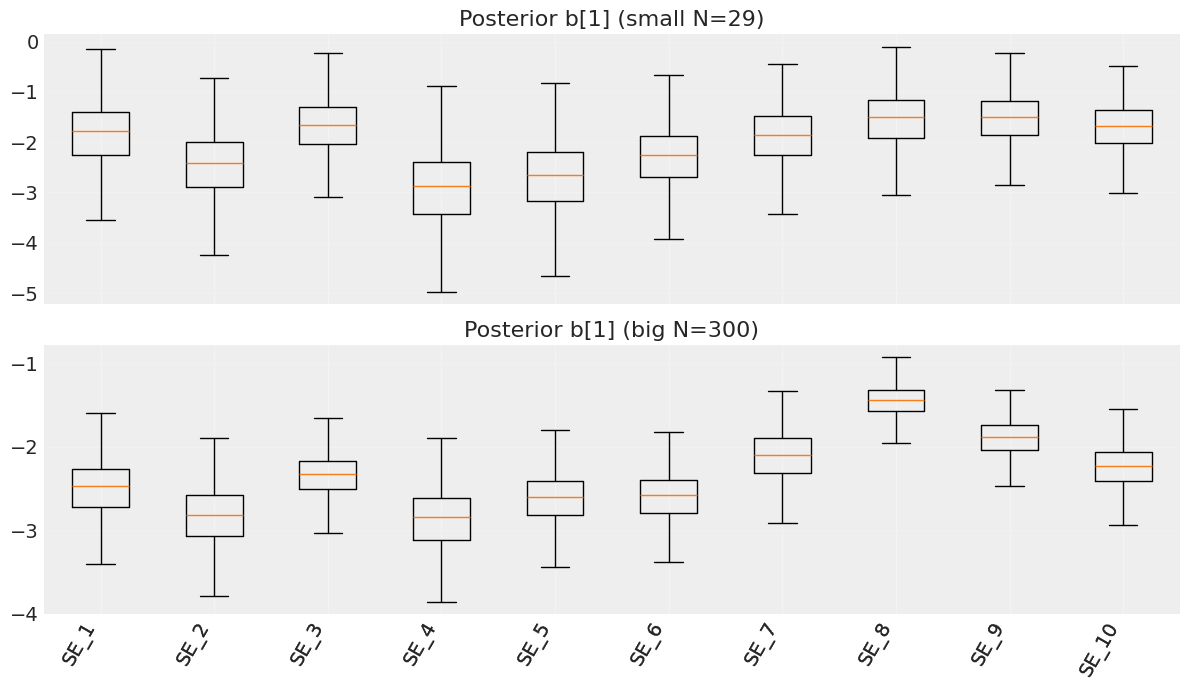

In [70]:
# b는 차원이 크므로 b[1]만 예시 비교(원하면 b[2], b[3]도 반복)
k_idx = 0
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].boxplot(b_s[:, :, k_idx], labels=SE_cols, showfliers=False)
axes[0].set_title(f"Posterior b[{k_idx+1}] (small N={N_small})"); axes[0].grid(alpha=0.2)

axes[1].boxplot(b_b[:, :, k_idx], labels=SE_cols, showfliers=False)
axes[1].set_title(f"Posterior b[{k_idx+1}] (big N={N_big})"); axes[1].grid(alpha=0.2)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [71]:
all_cols = SE_cols + AS_cols + IS_cols
common_idx = df[all_cols].dropna().index
df_common = df.loc[common_idx].copy()

df_se_c, K_se_c = prepare_items(df_common[SE_cols])
df_as_c, K_as_c = prepare_items(df_common[AS_cols])
df_is_c, K_is_c = prepare_items(df_common[IS_cols])

_, idata_se_c = fit_grm_mcmc(df_se_c, K_se_c, seed=501, adapt_delta=0.98)
_, idata_as_c = fit_grm_mcmc(df_as_c, K_as_c, seed=502, adapt_delta=0.98)
_, idata_is_c = fit_grm_mcmc(df_is_c, K_is_c, seed=503, adapt_delta=0.98)

def theta_median(idata):
    th = idata.posterior["theta"].values.reshape(-1, idata.posterior["theta"].shape[-1])  # (D,N)
    return np.median(th, axis=0)

theta_se = theta_median(idata_se_c)
theta_as = theta_median(idata_as_c)
theta_is = theta_median(idata_is_c)

latent_df = pd.DataFrame({"theta_SE": theta_se, "theta_AS": theta_as, "theta_IS": theta_is})
latent_df.corr()

13:43:52 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   5%|▌         | 100/2000 [00:01<00:32, 59.07it/s, (Warmup)]



chain 1:  10%|█         | 200/2000 [00:04<00:42, 42.32it/s, (Warmup)]

chain 1:  15%|█▌        | 300/2000 [00:06<00:36, 46.39it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:08<00:31, 50.68it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:10<00:32, 46.14it/s, (Warmup)]



chain 1:  30%|███       | 600/2000 [00:12<00:27, 50.81it/s, (Warmup)]

chain 1:  35%|███▌      | 700/2000 [00:13<00:23, 55.41it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:15<00:20, 57.27it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:17<00:19, 56.30it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:19<00:18, 55.38it/s, (Sampling)]





chain 1:  60%|██████    | 1200/2000 [00:22<00:14, 54.36it/s, (Sampling)]


chain 1:  65%|██████▌   | 1300/2000 [00:25<00:14, 48.02it/s, (Sampling)]


chain 


13:44:32 - cmdstanpy - INFO - CmdStan done processing.
13:44:32 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -2.33703e-61, but should be greater than the previous element, -2.33703e-61 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -2.35812e-61, but should be greater than the previous element, -2.35812e-61 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -2.71006e-110, but should be greater than the previous element, -2.71006e-110 (in 'grm_unidim.stan', line 24, column 6 to column 63)
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -6.34429e-95, but should be greater than the previous element, -6.34429e-95 (in 'grm_unidim.stan', line 24, column 6 

13:44:32 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]




chain 1:   5%|▌         | 100/2000 [00:06<02:12, 14.29it/s, (Warmup)]

chain 1:  10%|█         | 200/2000 [00:18<02:48, 10.68it/s, (Warmup)]

chain 1:  15%|█▌        | 300/2000 [00:26<02:31, 11.21it/s, (Warmup)]



chain 1:  20%|██        | 400/2000 [00:33<02:10, 12.25it/s, (Warmup)]

chain 1:  25%|██▌       | 500/2000 [00:42<02:05, 11.99it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:48<01:47, 13.07it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:55<01:39, 13.12it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [01:03<01:29, 13.34it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [01:10<01:21, 13.55it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [01:18<01:14, 13.35it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [01:26<01:09, 12.89it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [01:33<01:01, 13.05it/s, (Sampling)]


chain 1


13:47:14 - cmdstanpy - INFO - CmdStan done processing.
13:47:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -2.31772e-19, but should be greater than the previous element, -2.31772e-19 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -6.12684e-19, but should be greater than the previous element, -6.12684e-19 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -4.32864e-28, but should be greater than the previous element, -4.32864e-28 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -1.82209e-220, but should be greater than the previous element, -1.82209e-220 (in 'grm_unidim.stan', line 24, column 6

13:47:15 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:08<02:42, 11.72it/s, (Warmup)]





chain 1:   5%|▌         | 100/2000 [00:22<02:42, 11.72it/s, (Warmup)]




chain 1:  10%|█         | 200/2000 [00:33<05:23,  5.57it/s, (Warmup)]



chain 1:  20%|██        | 400/2000 [00:50<03:07,  8.56it/s, (Warmup)]



chain 1:  25%|██▌       | 500/2000 [00:59<02:41,  9.31it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [01:08<02:19, 10.04it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [01:16<02:04, 10.42it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [01:26<01:56, 10.29it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [01:36<01:46, 10.37it/s, (Warmup)]






chain 1:  50%|█████     | 1000/2000 [01:48<01:45,  9.50it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [02:01<01:40,  8.93it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [02:15<01:35,  8.35it/s, (Sampling)]




13:51:31 - cmdstanpy - INFO - CmdStan done processing.
13:51:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -2.01082e-81, but should be greater than the previous element, -2.01082e-81 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -2.56889e-06, but should be greater than the previous element, -2.56889e-06 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -4.81197e-20, but should be greater than the previous element, -4.81197e-20 (in 'grm_unidim.stan', line 24, column 6 to column 63)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -4.48587e-89, but should be greater than the previous element, -4.48587e-89 (in 'grm_unidim.stan', line 24, column 6 t

,theta_SE,theta_AS,theta_IS
theta_SE,1.000000,-0.476381,0.291603
theta_AS,-0.476381,1.000000,-0.322876
theta_IS,0.291603,-0.322876,1.000000


/tmp/ipykernel_32444/202132159.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


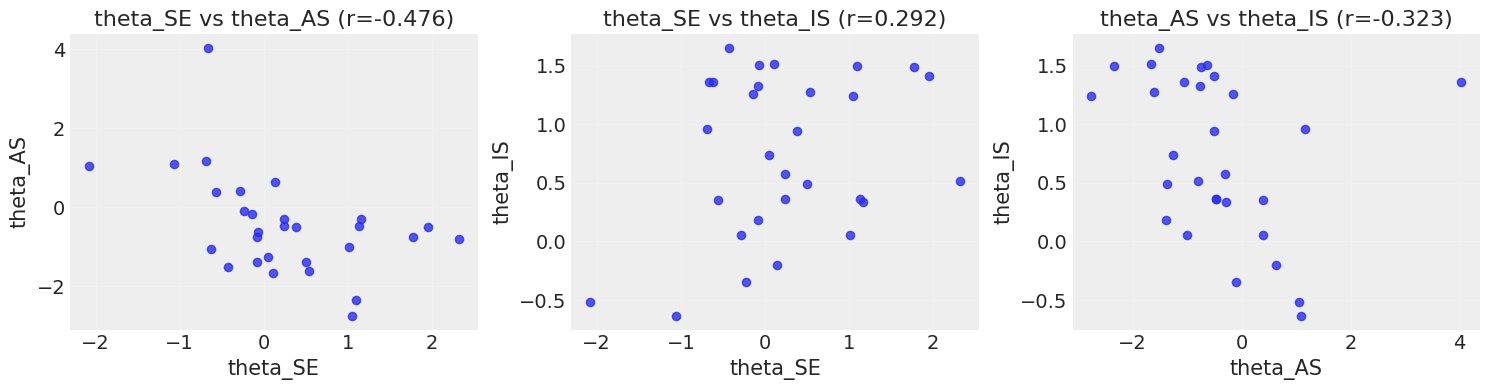

In [72]:
pairs = [("theta_SE","theta_AS"), ("theta_SE","theta_IS"), ("theta_AS","theta_IS")]
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (x,y) in zip(axes, pairs):
    ax.scatter(latent_df[x], latent_df[y], s=35, alpha=0.8)
    r = np.corrcoef(latent_df[x], latent_df[y])[0,1]
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y} (r={r:.3f})")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()